In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
import os
import tempfile

# Numerical computing
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Single-cell analysis
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# R interface — used to call Nebula (an R package) from Python
import rpy2.robjects as ro

# Load environment variables from .env (e.g. path to the Nebula shell script)
from dotenv import load_dotenv
load_dotenv()

# Project utility modules
from utils import preprocessing
from utils import DEG

%matplotlib inline

# Path to the shell script that distributes Nebula gene chunks across cores
PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

# Config

In [2]:
### Download bican data from macosko bcujet
    # gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/Full_Objects/STR_D1_Matrix_MSN.h5ad
    # gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Raw_Objects/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BICAN_PATH  = "/home/gdallagl/myworkdir/XDP/data/BICAN/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"
SAVE_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# ── obs column names in BICAN (set once, used everywhere) ──────────────────────
SAMPLE_VARIABLE  = "donor_id"      # unique donor / sample identifier
AGE              = "age"           # donor age in years (continuous covariate)
ZONE_COL         = "zone"          # spatial zone label (integer 1-6)
LIBRARY_SIZE_COL = "total_counts"  # total UMI per cell; Nebula uses log(this) as offset
SEX_COL          = "sex"           # donor sex (encoded as 0/1 if stored as string)
PC_COLS          = ["PC1", "PC2", "PC3", "PC4", "PC5"]  # SNP-derived PCs; control for genetic ancestry

# ── Thresholds ─────────────────────────────────────────────────────────────────
REF_ZONE           = 4     # reference zone for dummy encoding (all other zones compared to this)
MIN_CELLS_PER_ZONE = 30    # drop a (donor, zone) pair if fewer than this many cells
MIN_CELLS_GENE     = 50    # drop a gene if expressed in fewer than this many cells across the whole dataset
MIN_COUNTS_GENE    = 100   # drop a gene if its total count is below this
DR_THR             = 0.05   # a gene is "lowly expressed" if mean detection rate < this threshold

# Load BICAN

In [4]:
# Load the BICAN D1 Matrix AnnData from disk
bican = sc.read_h5ad(BICAN_PATH)

# Rename obs columns to the standard names defined in Config
bican.obs = bican.obs.rename(columns={
    "merge_step_6": ZONE_COL,         # ATTENTION; this is final col deifned by matthiew
    "n_counts":     LIBRARY_SIZE_COL, # total UMI counts per cell
    "imputed_sex":  SEX_COL,          # computationally inferred sex
})

# Sanity check: print basic dataset dimensions and ranges
print(bican)
print(f"Donors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Age    : {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f} years")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")

# Replace .X with the raw integer counts stored in the 'counts' layer
# Nebula requires raw counts — not normalized or log-transformed values
bican.X = bican.layers["counts"].copy()

AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 'scpred_c

# Filter Bad samples

With not enough zones or all cioming from same zone

,donor_id,zone,n_cells,age
0,MD6366,1,889,31
1,MD6366,2,357,31
2,MD6366,3,197,31
3,MD6366,4,115,31
4,MD6366,5,96,31
...,...,...,...,...
836,UMBEB24009,2,166,49
837,UMBEB24009,3,113,49
838,UMBEB24009,4,1892,49
839,UMBEB24009,5,189,49


/tmp/ipykernel_3473434/3614934838.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_zones_per_donor = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["n_cells"].count()
2026-06-02 18:52:46 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 18:52:46 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


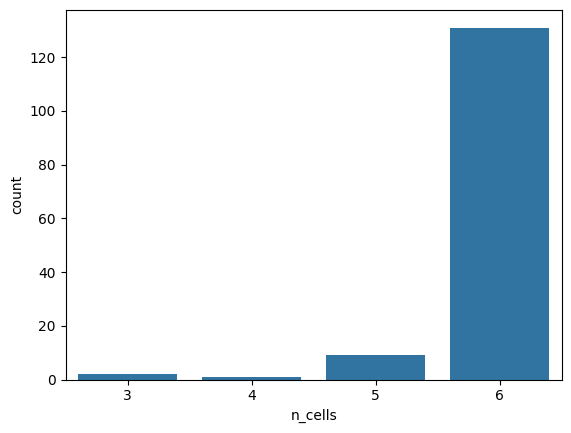

Donors with all 6 zones: 131 / 143 = 91.61%


/tmp/ipykernel_3473434/3614934838.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(SAMPLE_VARIABLE)["n_cells"]
/tmp/ipykernel_3473434/3614934838.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(SAMPLE_VARIABLE)["n_cells"].max().reset_index(name="proportion_max_zone")


,donor_id,proportion_max_zone
0,MD6366,0.499438
1,MD6417,0.320197
2,MD6424,0.460798
3,MD6429,0.478095
4,MD6432,0.346638
...,...,...
138,UMBEB23073,0.292419
139,UMBEB23076,0.343475
140,UMBEB23083,0.974194
141,UMBEB23100,0.540193


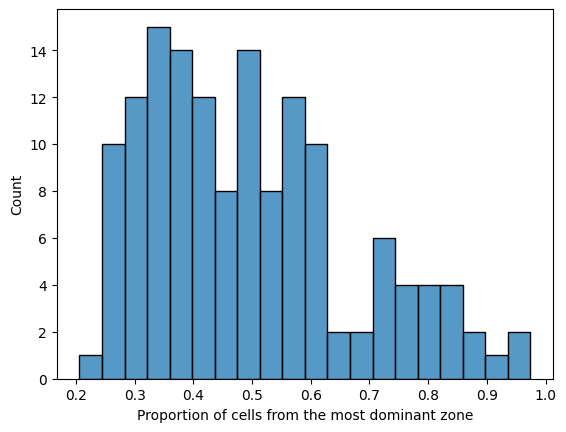

Donors with >X% of cells from one zone: 33 / 143 = 23.08%
Donors with >1000 cells in at least one zone: 20 / 143 = 13.99%


/tmp/ipykernel_3473434/3614934838.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donors_with_zone_with_too_many_cells = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["zone_with_too_cells"].any().reset_index(name="donor_has_zone_with_too_many_cells")
/tmp/ipykernel_3473434/3614934838.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donors_with_zone_with_too_few_cells = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["zone_with_too_few_cells"].sum().reset_index(name="n_zones_with_too_few_cells_per_donor")
2026-06-02 18:52:46 | [INFO] Using categorical units to plot a list of strings that are all parsabl

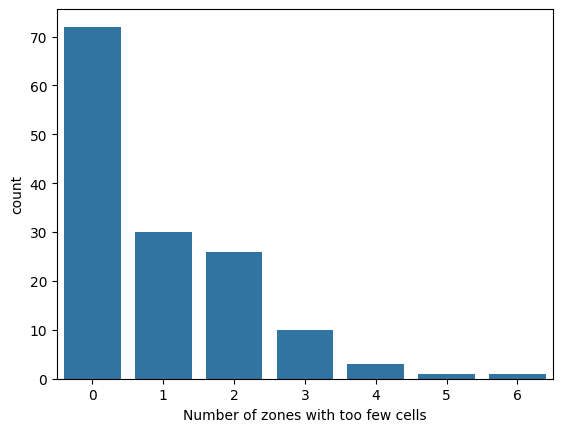

Donors with at least 3 zone with <30 cells: 15 / 143 = 10.49%
96


In [5]:
# Check if cells per zone per donor correlates with age
cells_per_zone_donor = (
    bican.obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(bican.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
)
display(cells_per_zone_donor)

# Check how many donors have all 6 zones represented with at least MIN_CELLS_PER_ZONE cells
n_zones_per_donor = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["n_cells"].count()
sns.countplot(x=n_zones_per_donor); plt.show()
donors_with_6_zones = n_zones_per_donor[n_zones_per_donor == 6].index
print(f"Donors with all 6 zones: {len(donors_with_6_zones)} / {bican.obs[SAMPLE_VARIABLE].nunique()} = {len(donors_with_6_zones) / bican.obs[SAMPLE_VARIABLE].nunique():.2%}")  

# Check which donors have cells coming almost from on zone only (e.g. >50% of their cells from a single zone)
cells_per_donor_zone = (
    cells_per_zone_donor
    .groupby(SAMPLE_VARIABLE)["n_cells"]
    .apply(lambda x: x / x.sum())  # convert to proportions
    .reset_index()
).groupby(SAMPLE_VARIABLE)["n_cells"].max().reset_index(name="proportion_max_zone")
display(cells_per_donor_zone)
sns.histplot(cells_per_donor_zone["proportion_max_zone"], bins=20); plt.xlabel("Proportion of cells from the most dominant zone"); plt.show()
donors_dominated_by_one_zone = cells_per_donor_zone[cells_per_donor_zone["proportion_max_zone"] > 0.6][SAMPLE_VARIABLE].unique()
print(f"Donors with >X% of cells from one zone: {len(donors_dominated_by_one_zone)} / {bican.obs[SAMPLE_VARIABLE].nunique()} = {len(donors_dominated_by_one_zone) / bican.obs[SAMPLE_VARIABLE].nunique():.2%}")

# remve samples that ave too many cells in one zone
cells_per_zone_donor["zone_with_too_cells"] = cells_per_zone_donor["n_cells"] > 1000
donors_with_zone_with_too_many_cells = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["zone_with_too_cells"].any().reset_index(name="donor_has_zone_with_too_many_cells")
donors_with_zone_with_too_many_cells = donors_with_zone_with_too_many_cells[donors_with_zone_with_too_many_cells["donor_has_zone_with_too_many_cells"]][SAMPLE_VARIABLE].unique()
print(f"Donors with >1000 cells in at least one zone: {len(donors_with_zone_with_too_many_cells)} / {bican.obs[SAMPLE_VARIABLE].nunique()} = {len(donors_with_zone_with_too_many_cells) / bican.obs[SAMPLE_VARIABLE].nunique():.2%}")   

# Remvoe sample that have more than N zones with too few cells
cells_per_zone_donor["zone_with_too_few_cells"] = cells_per_zone_donor["n_cells"] < MIN_CELLS_PER_ZONE
donors_with_zone_with_too_few_cells = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["zone_with_too_few_cells"].sum().reset_index(name="n_zones_with_too_few_cells_per_donor")
sns.countplot(x=donors_with_zone_with_too_few_cells["n_zones_with_too_few_cells_per_donor"]); plt.xlabel("Number of zones with too few cells"); plt.show()
donors_with_zone_with_too_few_cells = donors_with_zone_with_too_few_cells[donors_with_zone_with_too_few_cells["n_zones_with_too_few_cells_per_donor"] > 2][SAMPLE_VARIABLE].unique()
print(f"Donors with at least 3 zone with <{MIN_CELLS_PER_ZONE} cells: {len(donors_with_zone_with_too_few_cells)} / {bican.obs[SAMPLE_VARIABLE].nunique()} = {len(donors_with_zone_with_too_few_cells) / bican.obs[SAMPLE_VARIABLE].nunique():.2%}")

#define donor to keep
donors_to_keep = set(donors_with_6_zones) - set(donors_dominated_by_one_zone) - set(donors_with_zone_with_too_many_cells) - set(donors_with_zone_with_too_few_cells)
print(len(donors_to_keep))


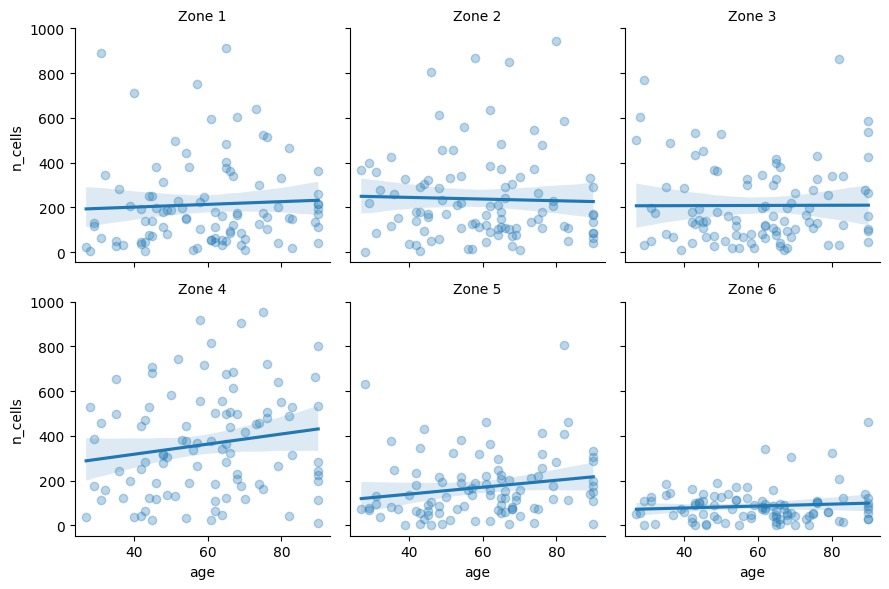

In [6]:
# Check if cells per zone per donor correlates with 
filtered_obs = bican[bican.obs[SAMPLE_VARIABLE].isin(donors_to_keep)].obs.copy()

cells_per_zone_donor = (
    filtered_obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(filtered_obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
)

import seaborn as sns
g = sns.lmplot(data=cells_per_zone_donor, x=AGE, y="n_cells",
               col=ZONE_COL, col_wrap=3, height=3, scatter_kws={"alpha": 0.3})
g.set_titles("Zone {col_name}")
plt.show()


In [7]:
# filter out
print(bican)
bican = bican[bican.obs[SAMPLE_VARIABLE].isin(donors_to_keep)].copy()
bican.obs[SAMPLE_VARIABLE].nunique()

AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 'scpred_c

96

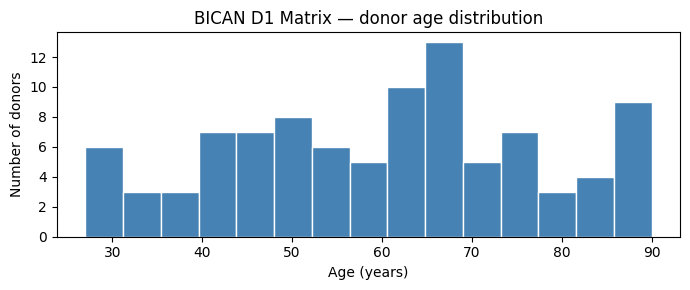

In [8]:
# Keep one row per donor (all cells from the same donor share the same age)
donor_ages = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)

# Histogram of donor ages — sanity check on the cohort demographics
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(donor_ages, bins=15, color="steelblue", edgecolor="white")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN D1 Matrix — donor age distribution")
plt.tight_layout()
plt.show()

# Filter bad genes

In [9]:
# Prefixes that identify genes adding technical noise or lacking reliable annotations
BAD_PREFIXES = (
    "MT-", "MTRNR",       # mitochondrial — elevated in damaged / low-quality cells
    "RPL", "RPS",         # ribosomal proteins — dominate counts, not informative here
    "HBB", "HBA", "HBG",  # hemoglobin — blood contamination
    "HBD", "HBE", "HBZ",
    "ENSG",               # raw Ensembl IDs — no gene symbol assigned
    "LINC",               # long intergenic non-coding RNAs — poorly characterized
)

# Put all gene names in a pandas Series so we can use string methods
gene_names = pd.Series(bican.var_names)

# For each gene, check if its name (uppercased) starts with any bad prefix
is_bad = gene_names.str.upper().apply(lambda name: any(name.startswith(p) for p in BAD_PREFIXES))

# Keep only the genes that are NOT flagged as bad
bican = bican[:, ~is_bad.values].copy()
print(f"After bad-prefix filter: {bican.n_vars} genes")

# Remove genes expressed in too few cells (unreliable count statistics)
sc.pp.filter_genes(bican, min_cells=MIN_CELLS_GENE)
# Remove genes whose total count across all cells is too low
sc.pp.filter_genes(bican, min_counts=MIN_COUNTS_GENE)
print(f"After count-based filter: {bican.n_vars} genes")

After bad-prefix filter: 22866 genes
After count-based filter: 20784 genes


### Flag fi you want to run analyss wiht age permutation

In [10]:
# Set PERMUTE_AGE = True to shuffle donor ages before any analysis.
PERMUTE_AGE = False

if PERMUTE_AGE:

    # Get one age value per donor (same value repeated for all cells of that donor)
    donor_age_series = (
        bican.obs
        .drop_duplicates(SAMPLE_VARIABLE)
        .set_index(SAMPLE_VARIABLE)[AGE]
        .astype(float)
    )

    # Shuffle the age values across donors (each donor gets a different donor's real age)
    shuffled_values = donor_age_series.sample(frac=1, random_state=42).values

    # Build a donor_id -> shuffled_age mapping
    permuted_age_map = pd.Series(shuffled_values, index=donor_age_series.index)

    # Overwrite the age column in .obs — all cells from the same donor get the same shuffled age
    bican.obs[AGE] = bican.obs[SAMPLE_VARIABLE].map(permuted_age_map)

    print("WARNING: PERMUTATION MODE active — donor ages are shuffled. This is a null control.")
    print(bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].head(10))

else:
    print("Standard mode — real donor ages used.")

Standard mode — real donor ages used.


# Define Young (Q1) and Old (Q4) donors

In [11]:
# Build a one-row-per-donor table with just the age column
donor_meta = (
    bican.obs
    .drop_duplicates(SAMPLE_VARIABLE)   # one row per donor
    .set_index(SAMPLE_VARIABLE)         # donor_id becomes the index
    [[AGE]]                             # keep only the age column
    .astype(float)
)

# Age cutoffs: 25th percentile (upper bound for Young) and 75th (lower bound for Old)
q25 = donor_meta[AGE].quantile(0.25)
q75 = donor_meta[AGE].quantile(0.75)

# Young = bottom quartile (Q1);  Old = top quartile (Q4)
# ATTNETION Q2/Q3 donors are excluded here but included in Nebula with continuous age
young_donors = donor_meta[donor_meta[AGE] <= q25].index.tolist()
old_donors   = donor_meta[donor_meta[AGE] >= q75].index.tolist()

print(f"Young (age <= {q25:.0f}): n = {len(young_donors)}")
print(f"Old   (age >= {q75:.0f}): n = {len(old_donors)}")

Young (age <= 46): n = 24
Old   (age >= 71): n = 24


# Zone filtering for Y/O donors
Each donor has cells spread across up to 6 spatial zones.
Zones with < MIN_CELLS_PER_ZONE cells give unreliable DR estimates, so we remove those cells.

If a donor ends up with 0 valid zones after filtering, they are implicitly absent from the DR dict
and simply do not contribute to any (zone, group) mean_DR computation — no special handling needed.

In [12]:
# cells_per_zone_donor = (
#     bican.obs
#     .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
#     .size()
#     .reset_index(name="n_cells")
#     .merge(bican.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
# )
# cells_per_zone_donor["zone_with_too_few_cells"] = cells_per_zone_donor["n_cells"] < MIN_CELLS_PER_ZONE
# display(cells_per_zone_donor[cells_per_zone_donor["zone_with_too_few_cells"]])
# a = cells_per_zone_donor.groupby(SAMPLE_VARIABLE)["zone_with_too_few_cells"].sum()

# sns.countplot(x=a); plt.xlabel("Number of zones with too few cells"); plt.show()

In [13]:
# # Combine young and old donor IDs into a single list
# yo_donors = young_donors + old_donors

# # Subset the full AnnData to Y/O donors only — DR is computed only on these
# bican_yo = bican[bican.obs[SAMPLE_VARIABLE].isin(yo_donors)].copy()

# # Count how many cells each (donor, zone) pair has
# cells_per_pair = (
#     bican_yo.obs
#     .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)  # one row per (donor, zone) combination
#     .size()
#     .reset_index(name="n_cells")
# )

# # Keep only (donor, zone) pairs with enough cells for a reliable DR estimate
# valid_pairs = cells_per_pair[cells_per_pair["n_cells"] >= MIN_CELLS_PER_ZONE]

# # Build a set 
# valid_set = set(zip(valid_pairs[SAMPLE_VARIABLE], valid_pairs[ZONE_COL]))

# # Create a boolean Series: True for each cell whose (donor, zone) pair is valid
# pair_labels = list(zip(bican_yo.obs[SAMPLE_VARIABLE], bican_yo.obs[ZONE_COL]))
# keep_mask   = pd.Series(pair_labels).isin(valid_set).values

# # Drop cells from sparse (donor, zone) pairs
# bican_yo = bican_yo[keep_mask].copy()

# # Report coverage: how many zones each donor retains after filtering
# # Donors with 0 valid zones are simply absent from bican_yo — no special handling needed
# n_zones_per_donor = bican_yo.obs.groupby(SAMPLE_VARIABLE, observed=True)[ZONE_COL].nunique()
# print(f"Valid (donor, zone) pairs : {len(valid_set)}")
# print(f"Zones per donor  —  min: {n_zones_per_donor.min()}  mean: {n_zones_per_donor.mean():.1f}  max: {n_zones_per_donor.max()}")

# Compute DR per (donor, zone)
DR = detection rate = fraction of cells in a (donor, zone) pair that express a gene (count > 0).
Each donor contributes one DR array per zone it has valid cells in (1 to 6 values per donor).

In [14]:
# Combine young and old donor IDs into a single list
yo_donors = young_donors + old_donors

# Subset the full AnnData to Y/O donors only — DR is computed only on these
bican_yo = bican[bican.obs[SAMPLE_VARIABLE].isin(yo_donors)].copy()

In [15]:
"""
What you're measuring: for each gene, you ask "in what fraction of cells do I see it at all?" If that fraction is low, you call the gene "lowly expressed."
The problem: that measurement depends on how many cells you looked at. The more cells you check, the more chances you have to catch a gene at least once — so genes stop looking "low" just because you looked harder, not because anything changed biologically.
How that hit your data: your samples have very different cell counts (from ~2,000 up to ~9,800). Zone 4 Old had almost double the cells of the others, so lots of genes got "caught" and stopped looking low — that's why zone 4 Old looked like an odd one out. It wasn't biology, just more fishing.
The GOOD news: for the Young-vs-Old comparison, the bias actually works in your favor. Old samples have more cells, which should make fewer genes look low for Old. But Old still ended up with more low genes than Young. So the age difference pushed through despite the bias fighting against it — which makes you more confident it's real.
"""

# Tag each cell with its age group
obs = bican_yo.obs.copy()
obs["group"] = np.where(obs[SAMPLE_VARIABLE].isin(young_donors), "Y", "O")

# Total cells per (zone, group)
n_cells = obs.groupby([ZONE_COL, "group"]).size()

display(n_cells) #ZONE 4 HAS MUCH MMORE CELLS THAN OHER ZONES

# how many cells per (donor, zone) combo
counts = n_cells_per_donor_zone["n_cells"].values

# For a range of candidate targets, how many pairs would survive?
targets = np.arange(50, counts.max(), 25)
retained = [(counts >= t).sum() for t in targets]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(targets, retained, marker="o", ms=3)
ax.axhline(len(counts), color="grey", ls="--", label=f"all {len(counts)} pairs")
ax.set_xlabel("N_TARGET"); ax.set_ylabel("pairs retained"); ax.legend()
plt.show()

zone  group
1     O        5594
      Y        4129
2     O        5837
      Y        4893
3     O        6232
      Y        6025
4     O        9825
      Y        7239
5     O        5647
      Y        3578
6     O        2397
      Y        2008
dtype: int64

NameError: name 'n_cells_per_donor_zone' is not defined

In [16]:
import numpy as np

# Subsample every (donor, zone) to this many cells — set fairly across all pairs
N_TARGET = 100
rng = np.random.default_rng(0)   # fixed seed = reproducible draw

# Gene names in the same order as columns in the count matrix
gene_names = bican_yo.var_names.tolist()

# Result dictionary: (donor, zone) -> numpy array of shape (n_genes,) with DR values in [0, 1]
dr_per_pair = {}

# Loop over every Y/O donor present in the filtered AnnData
for donor in bican_yo.obs.sort_values(AGE)[SAMPLE_VARIABLE].unique():

    # Boolean mask selecting all cells from this donor
    is_this_donor = bican_yo.obs[SAMPLE_VARIABLE] == donor

    # Get the zones that have valid cells for this donor
    zones_for_donor = bican_yo.obs.loc[is_this_donor, ZONE_COL].unique()

    for zone in zones_for_donor:

        # Boolean mask selecting cells from this specific (donor, zone) pair
        is_this_pair = is_this_donor & (bican_yo.obs[ZONE_COL] == zone)

        # Integer positions of the cells in this pair
        idx = np.flatnonzero(is_this_pair.values)

        # Skip pairs with too few cells to subsample fairly
        if len(idx) < N_TARGET:
            continue

        # Randomly keep exactly N_TARGET cells (no replacement) — equalizes cell count
        idx = rng.choice(idx, size=N_TARGET, replace=False)

        # Extract the count matrix for these cells
        X = bican_yo[idx].X

        # Convert from sparse to dense if needed (arithmetic requires dense arrays)
        if sp.issparse(X):
            X = X.toarray()

        # Detection rate: for each gene, the fraction of cells where count > 0
        dr = (X > 0).mean(axis=0)   # shape: (n_genes,)

        # Store the DR vector for this (donor, zone) pair
        dr_per_pair[(donor, zone)] = dr

print(f"Computed DR for {len(dr_per_pair)} (donor, zone) pairs (subsampled to {N_TARGET} cells each)")

df_dr = pd.DataFrame.from_dict(dr_per_pair, orient='index', columns=gene_names)
df_dr.index = pd.MultiIndex.from_tuples(df_dr.index, names=['donor', 'zone'])
df_dr.index = df_dr.index.set_levels(df_dr.index.levels[1].astype('category'), level='zone')

df_dr

Computed DR for 198 (donor, zone) pairs (subsampled to 100 cells each)


TSPAN6  DPM1  SCYL3  C1orf112   FGR   CFH  FUCA2  GCLC  NFYA  \
donor    zone                                                                 
MD6429   3       0.02  0.93   0.57      0.96  0.01  0.01   0.36  0.99  0.41   
         2       0.01  0.96   0.66      0.96  0.02  0.04   0.39  0.98  0.44   
MD6432   3       0.00  0.92   0.68      0.74  0.03  0.04   0.30  1.00  0.44   
         5       0.02  0.91   0.66      0.69  0.02  0.01   0.37  0.99  0.37   
         4       0.04  0.96   0.82      0.78  0.00  0.02   0.37  0.99  0.50   
...               ...   ...    ...       ...   ...   ...    ...   ...   ...   
MS367449 2       0.01  1.00   0.63      0.67  0.00  0.01   0.18  0.99  0.18   
         3       0.02  0.99   0.69      0.78  0.04  0.03   0.36  0.99  0.34   
         6       0.05  1.00   0.73      0.88  0.02  0.08   0.38  1.00  0.40   
         5       0.04  0.98   0.74      0.91  0.02  0.04   0.35  0.98  0.35   
         4       0.05  0.97   0.74      0.90  0.02  0.01   0.30  0.99  0.32   

               STPG1  ...  DPY19L2P3  FAM86DP  SOD2  SMG1P7  SMG1P5  \
donor    zone         ...                                             
MD6429   3      0.39  ...       0.98     0.63  0.86    0.33    0.93   
         2      0.48  ...       0.98     0.65  0.90    0.35    0.95   
MD6432   3      0.54  ...       0.92     0.68  1.00    0.44    0.91   
         5      0.61  ...       0.90     0.62  0.97    0.36    0.93   
         4      0.55  ...       0.96     0.75  0.99    0.46    0.93   
...              ...  ...        ...      ...   ...     ...     ...   
MS367449 2      0.39  ...       0.95     0.46  0.82    0.33    0.91   
         3      0.39  ...       1.00     0.52  0.91    0.52    0.93   
         6      0.48  ...       0.98     0.57  0.88    0.47    0.97   
         5      0.52  ...       1.00     0.67  0.94    0.61    0.98   
         4      0.44  ...       0.98     0.57  0.93    0.37    0.92   

               ANKRD20A11P  COL6A4P1  PRSS30P  LY6S  TMEM276  
donor    zone                                                 
MD6429   3            0.75      0.01     0.02  0.01     0.34  
         2            0.81      0.00     0.02  0.01     0.36  
MD6432   3            1.00      0.04     0.02  0.00     0.40  
         5            1.00      0.02     0.01  0.00     0.45  
         4            1.00      0.01     0.02  0.01     0.45  
...                    ...       ...      ...   ...      ...  
MS367449 2            1.00      0.05     0.01  0.00     0.33  
         3            1.00      0.01     0.00  0.00     0.45  
         6            1.00      0.00     0.04  0.02     0.54  
         5            0.99      0.01     0.00  0.01     0.49  
         4            0.98      0.00     0.00  0.02     0.45  

[198 rows x 20784 columns]

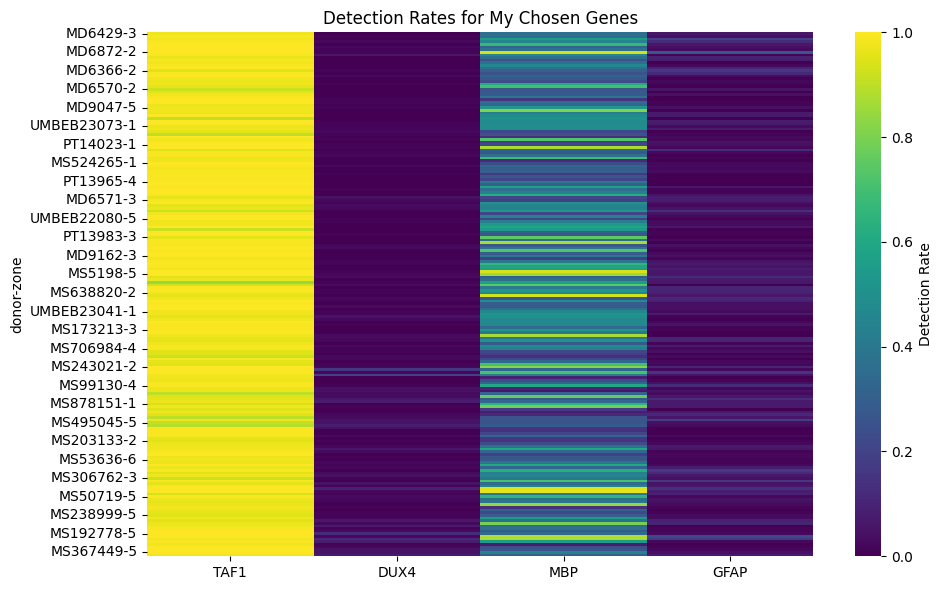

In [17]:
# Just put the exact gene names you want to see in this list.
my_genes_of_interest = ["TAF1", "DUX4", "MBP", "GFAP"]

# 3. Filter the data to ONLY include your chosen genes
df_subset = df_dr[my_genes_of_interest]

# 4. Plot the heatmap!
plt.figure(figsize=(10, 6))
# I added annot=True so the actual numbers show up inside the boxes
sns.heatmap(df_subset, cmap="viridis", annot=False, cbar_kws={'label': 'Detection Rate'})

plt.title("Detection Rates for My Chosen Genes")
plt.tight_layout()
plt.show()

# Find G: union of lowly expressed genes across all (zone x YO) combinations

For each of the 12 combinations (6 zones x 2 age groups Y/O):
  1. Average DR across donors in that group that have valid cells in that zone
  2. Flag genes where mean_DR < DR_THR as 'lowly expressed' in this combination

G = union across all 12 combinations.

Taking the union (rather than intersection) is the point:
- Whole-striatum derepressed genes appear in multiple zones -> captured
- Zone-specific derepressed genes appear only in one zone -> also captured
- No zone-specific signal is lost, and we get a single unified candidate list.

In [18]:
zones = sorted(bican_yo.obs[ZONE_COL].unique())

# Dict: (zone, group) -> mean DR array, shape (n_genes,)
mean_dr_per_pair = {}
G_genes = set()  # running union of lowly-expressed genes

for zone in zones:
    for group in ["Y", "O"]:

        # Pick the donors for this age group
        donors = young_donors if group == "Y" else old_donors

        # Grab DR arrays for donors that actually have cells in this zone
        dr_list = [dr_per_pair[(d, zone)] for d in donors if (d, zone) in dr_per_pair]

        # No donors here? skip
        if not dr_list:
            print(f"  Zone {zone}, {group}: skipping (0 donors)")
            continue

        # Mean DR across donors, then store it
        mean_dr = np.mean(dr_list, axis=0)
        mean_dr_per_pair[(zone, group)] = mean_dr

        # Collect genes below the threshold
        G_genes.update(g for g, dr in zip(gene_names, mean_dr) if dr < DR_THR)

        print(f"  Zone {zone}, {group}: {len(dr_list)} donors")

G = sorted(G_genes)
print(f"\nG = {len(G)} candidate genes")

# Build DataFrame, then add the double index
df_mean_dr = pd.DataFrame.from_dict(mean_dr_per_pair, orient="index", columns=gene_names)
df_mean_dr.index = pd.MultiIndex.from_tuples(df_mean_dr.index, names=["zone", "group"])

# Make both index levels categorical
df_mean_dr = df_mean_dr.astype({})  # no-op, kept for clarity
df_mean_dr.index = df_mean_dr.index.set_levels(
    [df_mean_dr.index.levels[0].astype("category"),   # zone
     df_mean_dr.index.levels[1].astype("category")],  # group
)
df_mean_dr

  Zone 1, Y: 12 donors
  Zone 1, O: 21 donors
  Zone 2, Y: 18 donors
  Zone 2, O: 19 donors
  Zone 3, Y: 18 donors
  Zone 3, O: 20 donors
  Zone 4, Y: 19 donors
  Zone 4, O: 22 donors
  Zone 5, Y: 9 donors
  Zone 5, O: 20 donors
  Zone 6, Y: 11 donors
  Zone 6, O: 9 donors

G = 6268 candidate genes


TSPAN6      DPM1     SCYL3  C1orf112       FGR       CFH  \
zone group                                                               
1    Y      0.014167  0.935833  0.644167  0.603333  0.015000  0.022500   
     O      0.013810  0.936667  0.519048  0.655714  0.010952  0.020476   
2    Y      0.015556  0.936667  0.639444  0.665556  0.015556  0.023889   
     O      0.011579  0.925263  0.544737  0.678421  0.015263  0.021579   
3    Y      0.013333  0.948333  0.685556  0.700000  0.014444  0.020000   
     O      0.013500  0.928500  0.594000  0.705500  0.018500  0.015000   
4    Y      0.018421  0.923158  0.722632  0.763158  0.013158  0.020526   
     O      0.020455  0.936364  0.648182  0.800909  0.017727  0.015909   
5    Y      0.022222  0.936667  0.703333  0.715556  0.020000  0.016667   
     O      0.014500  0.941500  0.616500  0.776500  0.015500  0.016500   
6    Y      0.012727  0.944545  0.690909  0.685455  0.019091  0.020000   
     O      0.017778  0.950000  0.620000  0.747778  0.020000  0.026667   

               FUCA2      GCLC      NFYA     STPG1  ...  DPY19L2P3   FAM86DP  \
zone group                                          ...                        
1    Y      0.287500  0.985833  0.437500  0.500000  ...   0.912500  0.553333   
     O      0.271905  0.957619  0.338095  0.439524  ...   0.949048  0.500000   
2    Y      0.341667  0.981111  0.403333  0.511111  ...   0.919444  0.553889   
     O      0.281053  0.963684  0.322105  0.457895  ...   0.940000  0.524211   
3    Y      0.376111  0.991111  0.432778  0.532222  ...   0.937222  0.605556   
     O      0.332500  0.975500  0.364000  0.474500  ...   0.942000  0.530000   
4    Y      0.360000  0.954211  0.438421  0.463158  ...   0.919474  0.643158   
     O      0.366364  0.959545  0.401818  0.444545  ...   0.947727  0.621364   
5    Y      0.327778  0.978889  0.434444  0.506667  ...   0.950000  0.601111   
     O      0.341000  0.972500  0.374000  0.456000  ...   0.957000  0.596000   
6    Y      0.305455  0.992727  0.453636  0.494545  ...   0.948182  0.628182   
     O      0.341111  0.973333  0.372222  0.456667  ...   0.953333  0.592222   

                SOD2    SMG1P7    SMG1P5  ANKRD20A11P  COL6A4P1   PRSS30P  \
zone group                                                                  
1    Y      0.885000  0.428333  0.936667     0.859167  0.021667  0.015000   
     O      0.807143  0.388095  0.890952     0.844762  0.019048  0.014762   
2    Y      0.891111  0.403333  0.926111     0.915000  0.013333  0.015556   
     O      0.820000  0.380526  0.900000     0.904737  0.027368  0.013684   
3    Y      0.901111  0.417222  0.930000     0.888333  0.015556  0.016111   
     O      0.849500  0.404000  0.899000     0.893000  0.020500  0.015000   
4    Y      0.880000  0.379474  0.918421     0.741053  0.021579  0.020000   
     O      0.866818  0.423636  0.924091     0.769091  0.020000  0.015909   
5    Y      0.910000  0.363333  0.934444     0.835556  0.007778  0.011111   
     O      0.867000  0.445500  0.927000     0.846500  0.017500  0.013500   
6    Y      0.911818  0.465455  0.948182     0.849091  0.012727  0.018182   
     O      0.862222  0.443333  0.920000     0.834444  0.016667  0.017778   

                LY6S   TMEM276  
zone group                      
1    Y      0.007500  0.495833  
     O      0.006667  0.325714  
2    Y      0.008333  0.514444  
     O      0.006316  0.374737  
3    Y      0.007222  0.574444  
     O      0.005000  0.436000  
4    Y      0.005263  0.530526  
     O      0.008182  0.406818  
5    Y      0.006667  0.511111  
     O      0.011000  0.386500  
6    Y      0.008182  0.517273  
     O      0.010000  0.390000  

[12 rows x 20784 columns]

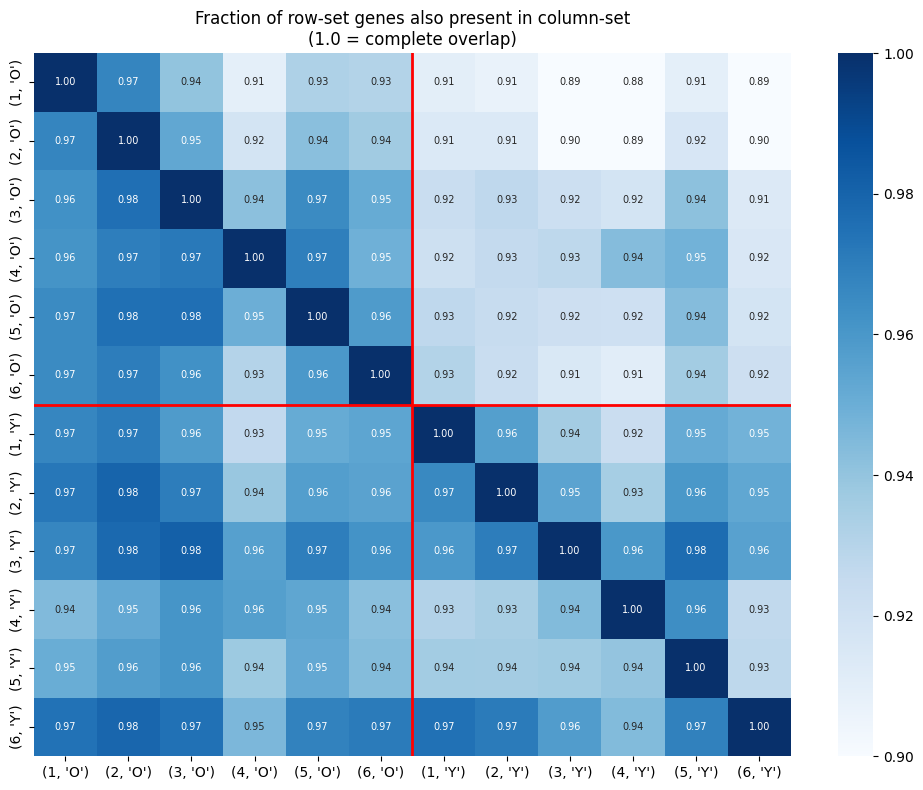

In [19]:
from itertools import product
import seaborn as sns

#what fraction of the row's low-DR genes are also low-DR in the column combination
    #1.00 → every gene that's lowly expressed in A is also lowly expressed in B.
#overlap[A, B] = |A ∩ B| / |A|
#overlap[B, A] = |A ∩ B| / |B|

#A set whose row is high but whose column is low is a small set
#Old combinations have more lowly-expressed genes, and the Young low genes are largely a subset of them.
#That contrast (light top-right, dark bottom-left) is the clean visual signature of Young ⊆ Old: Young low-DR genes are nearly a subset of Old's, and Old carries an extra ~5–13% of low genes that Young doesn't have.

# Low-DR gene set per (zone, group) — pulled directly from df_mean_dr (no recompute)
low_sets = {key: set(df_mean_dr.columns[row < DR_THR]) for key, row in df_mean_dr.iterrows()}

keys       = sorted(low_sets, key=lambda k: (k[1], k[0]))   # all O, then all Y
key_labels = [str(k) for k in keys]

overlap = pd.DataFrame(index=key_labels, columns=key_labels, dtype=float)
for key_a, key_b in product(keys, repeat=2):
    set_a, set_b = low_sets[key_a], low_sets[key_b]
    overlap.loc[str(key_a), str(key_b)] = len(set_a & set_b) / len(set_a) if set_a else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap, annot=True, fmt=".2f", cmap="Blues",
            vmin=0.9, vmax=1.0, ax=ax, annot_kws={"size": 7})

# Split into 4 quadrants at the O/Y boundary
n_old = sum(1 for k in keys if k[1] == "O")   # = 6
ax.axhline(n_old, color="red", lw=2)
ax.axvline(n_old, color="red", lw=2)

ax.set_title("Fraction of row-set genes also present in column-set\n(1.0 = complete overlap)")
plt.tight_layout()
plt.show()

In [20]:
"""
What you're measuring: for each gene, you ask "in what fraction of cells do I see it at all?" If that fraction is low, you call the gene "lowly expressed."
The problem: that measurement depends on how many cells you looked at. The more cells you check, the more chances you have to catch a gene at least once — so genes stop looking "low" just because you looked harder, not because anything changed biologically.
How that hit your data: your samples have very different cell counts (from ~2,000 up to ~9,800). Zone 4 Old had almost double the cells of the others, so lots of genes got "caught" and stopped looking low — that's why zone 4 Old looked like an odd one out. It wasn't biology, just more fishing.
The GOOD news: for the Young-vs-Old comparison, the bias actually works in your favor. Old samples have more cells, which should make fewer genes look low for Old. But Old still ended up with more low genes than Young. So the age difference pushed through despite the bias fighting against it — which makes you more confident it's real.


Since every pair now used exactly 100 cells, the cell-count explanation is off the table. The age difference is genuine.
"""

# Tag each cell with its age group
obs = bican_yo.obs.copy()
obs["group"] = np.where(obs[SAMPLE_VARIABLE].isin(young_donors), "Y", "O")

# Total cells per (zone, group)
n_cells = obs.groupby([ZONE_COL, "group"]).size()

# Number of low-DR genes per (zone, group), from the sets you already have
n_low = pd.Series({k: len(v) for k, v in low_sets.items()})

# Align both into one table (make sure the index keys match: (zone, group) tuples)
n_cells.index = [(z, g) for z, g in n_cells.index]
summary = pd.DataFrame({"n_low_genes": n_low}).sort_index()
print(summary)

     n_low_genes
1 O         5685
  Y         5352
2 O         5685
  Y         5304
3 O         5553
  Y         5218
4 O         5380
  Y         5305
5 O         5493
  Y         5440
6 O         5486
  Y         5206


In [21]:
"""
 PORBLME: oung cells were sequenced ~20–45% deeper than Old cells, in every zone. 

 
NOT IMPORTANT FOR NEBULA ALTER
 """

# Total counts per cell (use the existing column if you have one, e.g. 'total_counts' or 'n_counts')
obs["total_counts"] = np.asarray(bican_yo.X.sum(axis=1)).ravel()

# Median depth per zone — is zone 4 deeper than the rest?
print(obs.groupby(ZONE_COL)["total_counts"].median())
print(obs.groupby([ZONE_COL, "group"])["total_counts"].median())

zone
1     85322.0
2     95371.5
3     96386.0
4     92413.0
5     99339.0
6    108038.0
Name: total_counts, dtype: float64
zone  group
1     O         71857.0
      Y        103897.0
2     O         82804.0
      Y        110092.0
3     O         82089.5
      Y        110366.0
4     O         88812.0
      Y         98689.0
5     O         93767.0
      Y        106853.5
6     O         92915.0
      Y        121888.5
Name: total_counts, dtype: float64


# Prepare adata for Nebula (ALL donors, only G genes)
Nebula is run on all BICAN donors — not just Y/O — to use the full continuous age range.

Nebula accepts only flat numeric covariates, so we manually encode the zone x age interaction:
- zone_2 ... zone_6: dummy variables (1 if cell is in that zone)  — zone_1 = reference
- age_x_zone_2 ... age_x_zone_6: age * zone_k interaction terms

This is equivalent to the R formula:  ~ age * zone  (but pre-encoded as numeric columns)
Full Nebula model:  count ~ age + zone_2..6 + age:zone_2..6 + sex + PC1-5
                           + offset(log(total_counts)) + (1 | donor_id)

In [22]:
# Subset to ALL donors (not just Y/O) but only the G candidate genes
# Nebula uses the full continuous age range — not just the extremes used to define G
bican_nebula = bican[:, G].copy()

# Ensure .X holds raw integer counts (required by Nebula)
bican_nebula.X = bican_nebula.layers["counts"].copy()

# Zones other than the reference zone need dummy columns and interaction columns
non_ref_zones = [z for z in sorted(bican_nebula.obs[ZONE_COL].unique()) if z != REF_ZONE]

# Nebula accepts only flat numeric covariates — no formula syntax — so we pre-encode manually
for zone in non_ref_zones:

    # Zone dummy: 1 if this cell is in this zone, 0 otherwise (main zone effect)
    bican_nebula.obs[f"zone_{zone}"] = (bican_nebula.obs[ZONE_COL] == zone).astype(float)

    # Age × zone interaction: carries the donor's age for cells in this zone, 0 elsewhere
    # This encodes how much the age slope changes in zone k relative to the reference zone
    bican_nebula.obs[f"age_x_zone_{zone}"] = (
        bican_nebula.obs[AGE] * bican_nebula.obs[f"zone_{zone}"]
    )

# Encode sex as 0/1 numeric if it is stored as a string ('M'/'F')
if bican_nebula.obs[SEX_COL].dtype == object:
    bican_nebula.obs[SEX_COL] = (bican_nebula.obs[SEX_COL] == "M").astype(float)  # 1 = Male, 0 = Female

# Assemble the full covariate list (all must be numeric columns already in .obs)
ZONE_DUMMIES      = [f"zone_{z}"       for z in non_ref_zones]  # zone main effects
ZONE_INTERACTIONS = [f"age_x_zone_{z}" for z in non_ref_zones]  # age × zone interactions
NEBULA_COVARIATES = [AGE, *ZONE_DUMMIES, *ZONE_INTERACTIONS, SEX_COL, *PC_COLS]

# Drop any cell with a missing value in any covariate — Nebula cannot handle NaN
nan_mask = bican_nebula.obs[NEBULA_COVARIATES].isna().any(axis=1)
print(f"Dropping {nan_mask.sum()} cells with NaN covariates")
bican_nebula = bican_nebula[~nan_mask].copy()

print(bican_nebula)
print(f"\nNebula covariates ({len(NEBULA_COVARIATES)}): {NEBULA_COVARIATES}")

Dropping 0 cells with NaN covariates
AnnData object with n_obs × n_vars = 122641 × 6268
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred

# Run Nebula

In [23]:
# Cast count matrix to integer dtype — Nebula requires integer counts, not floats
bican_nebula.X = bican_nebula.layers["counts"].astype(int).copy()

In [24]:
# Output path for the Seurat .qs file (the format the Nebula R script reads)
QS_PATH = f"{SAVE_FOLDER}/bican_nebula.qs"

# Create a temporary directory to hold intermediate files for R conversion
tmp_dir = tempfile.mkdtemp(dir="/tmp")

# Write the count matrix and metadata in a format the R script can ingest
preprocessing.save_files_for_R_conversion(bican_nebula, tmp_dir)

# Build the Seurat .qs object from those files
preprocessing.build_qs_from_python_files(
    tmp_dir,
    saving_path     = QS_PATH,
    contrast_var    = None,   # no binary group contrast — age is continuous
    reference_level = None,
)

# Run Nebula across gene chunks in parallel and collect the result path
nebula_result_path = DEG.run_nebula_parallel_script(
    path_qs            = QS_PATH,
    path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
    id_col             = SAMPLE_VARIABLE,    # column grouping cells by donor (random effect)
    covs               = NEBULA_COVARIATES,  # flat list of pre-encoded numeric covariates
    offset_col         = LIBRARY_SIZE_COL,   # Nebula takes log(this) as the library-size offset
    n_folds            = 40,                 # split genes into 40 chunks (reduces RAM per job)
    n_cores            = 40,                 # run 40 chunks in parallel
    save_tmp           = False,
)

2026-06-02 19:00:42 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-06-02 19:00:42 | [WARNING] R callback write-console: Loading required package: sp
  
2026-06-02 19:00:43 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-06-02 19:00:43 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-06-02 19:00:45 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-06-02 19:00:45 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-06-02 19:00:45 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


[1] "Creating Seurat object..."


2026-06-02 19:01:01 | [WARNING] R callback write-console: Warning:  
2026-06-02 19:01:01 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs age,zone_1,zone_2,zone_3,zone_5,zone_6,age_x_zone_1,age_x_zone_2,age_x_zone_3,age_x_zone_5,age_x_zone_6,sex,PC1,PC2,PC3,PC4,PC5
[INFO]

# Save and inspect results

In [25]:
RESULTS_CSV = f"{SAVE_FOLDER}/nebula_results.csv"


In [26]:
# Read the Nebula result file in R, extract the summary table, and save it as CSV
ro.r(f'''
    library(qs)
    obj <- qread("{nebula_result_path}")   # load the Nebula result object (list with $summary, etc.)
    df  <- obj$summary                     # one row per gene, one column per covariate beta / p-value
    write.csv(df, "{RESULTS_CSV}", row.names=FALSE)
''')


In [27]:
# Load the CSV into a pandas DataFrame for all downstream analysis
df = pd.read_csv(RESULTS_CSV)
print(f"Results: {len(df)} genes")
display(df.head())

Results: 4837 genes


,logFC_(Intercept),logFC_age,logFC_zone_1,logFC_zone_2,logFC_zone_3,logFC_zone_5,logFC_zone_6,logFC_age_x_zone_1,logFC_age_x_zone_2,logFC_age_x_zone_3,...,p_age_x_zone_5,p_age_x_zone_6,p_sex,p_PC1,p_PC2,p_PC3,p_PC4,p_PC5,gene_id,gene
0,-14.703664,0.005208,-0.557130,0.181906,0.047519,0.297927,-0.734948,0.002947,-0.004513,-0.001536,...,0.059505,0.052643,0.415244,0.232011,0.579962,0.003674,0.901369,0.159291,1,A1CF
1,-15.451760,0.000980,-1.119062,-0.434915,-0.370884,-0.319283,-0.919936,0.002274,-0.001618,0.000420,...,0.787440,0.268208,0.897819,0.600802,0.263011,0.654584,0.317685,0.874728,3,A2MP1
2,-14.499305,0.000339,-0.186378,-0.222118,-0.383630,-0.241296,-0.421550,0.003170,0.003012,0.005851,...,0.132167,0.088285,0.932551,0.101015,0.731318,0.001829,0.207946,0.801888,4,A3GALT2
3,-16.859788,0.004742,-0.447071,-0.139954,0.560067,0.217700,-1.296007,0.003499,-0.002070,-0.011396,...,0.451134,0.452463,0.364486,0.594759,0.944634,0.007330,0.302226,0.756283,7,AADAC
4,-15.861456,0.006002,0.505293,0.093916,0.032775,0.164537,-0.307642,-0.006520,0.000556,-0.001022,...,0.481361,0.290387,0.927427,0.458961,0.135433,0.279892,0.185586,0.223505,10,AADACL4


In [28]:
# Quick ranking: which genes have the largest positive age coefficient?
# Higher logFC_age = expression increases most strongly with age in reference zone

from statsmodels.stats.multitest import multipletests

df_sig = df[["gene", "logFC_age", "p_age"]].dropna().copy()

df_sig["fdr_age"] = multipletests(df_sig["p_age"], method="fdr_bh")[1]

df_sig["log2FC_50yr"] = df_sig["logFC_age"] * 50 / np.log(2)

df_sig = df_sig[df_sig["fdr_age"] < 0.05].sort_values("logFC_age", ascending=False).head(30)

df_sig

,gene,logFC_age,p_age,fdr_age,log2FC_50yr
1233,DUX4,0.042164,2.134244e-14,1.290417e-11,3.041465
4363,TMEM26-AS1,0.039834,1.746139e-17,2.815359e-14,2.873444
146,ALDH1L1,0.037374,5.986557e-06,2.632452e-04,2.695962
1208,DRGX,0.037111,8.010808e-06,3.256158e-04,2.676981
2667,MT1M,0.036788,5.958160e-05,1.378929e-03,2.653660
3334,PPP1R14A,0.035916,6.358798e-06,2.746206e-04,2.590803
3988,SNTG2-AS1,0.033979,1.104690e-03,1.166678e-02,2.451075
3985,SNCG,0.033771,1.488915e-04,2.857890e-03,2.436073
2493,MARCKSL1,0.033139,9.698115e-04,1.056527e-02,2.390496
625,CBLN2,0.032674,2.761303e-15,3.339106e-12,2.356904


,covariate,n_genes,median,pct_pos,wilcoxon_p
0,logFC_age (signal),4837,0.00181,63.4%,2.83e-104
1,logFC_sex (control),4837,0.00125,50.5%,9.96e-01
2,logFC_age_x_zone_2 (control),4837,-0.00109,41.8%,1.00e+00


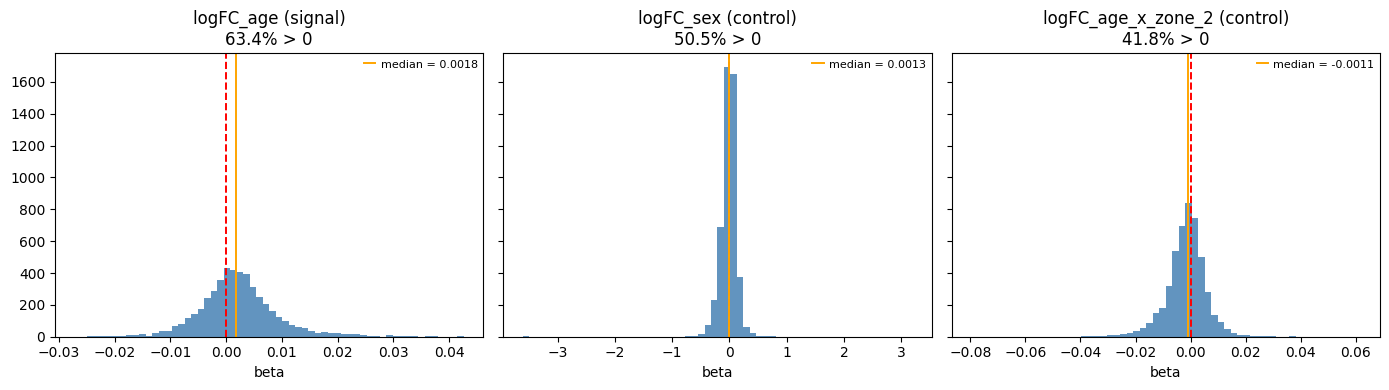

In [29]:
from scipy.stats import wilcoxon

# logFC_sex and logFC_age_x_zone_2 were not used to define G → expected symmetric around 0.
# If only logFC_age is right-skewed, the age signal is real, not a Nebula/selection artifact.
CONTROLS = {
    f"logFC_{AGE} (signal)":         f"logFC_{AGE}",
    "logFC_sex (control)":           "logFC_sex",
    "logFC_age_x_zone_2 (control)":  "logFC_age_x_zone_2",
}

rows = []
for label, col in CONTROLS.items():
    vals = df[col].dropna()
    _, pval = wilcoxon(vals, alternative="greater")
    rows.append({
        "covariate": label,
        "n_genes":   len(vals),
        "median":    round(vals.median(), 5),
        "pct_pos":   f"{(vals > 0).mean() * 100:.1f}%",
        "wilcoxon_p": f"{pval:.2e}" if pval > 0 else "< 2.2e-16  (underflow)",
    })

display(pd.DataFrame(rows))

# Visual comparison: three histograms on the same x-axis
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (label, col) in zip(axes, CONTROLS.items()):
    vals = df[col].dropna()
    ax.hist(vals, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(0,             color="red",    linestyle="--", lw=1.4)
    ax.axvline(vals.median(), color="orange", linestyle="-",  lw=1.4,
               label=f"median = {vals.median():.4f}")
    ax.set_title(f"{label}\n{(vals > 0).mean()*100:.1f}% > 0")
    ax.set_xlabel("beta")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# Plot beta_age distribution
If de-repression is active across G genes, the distribution of age coefficients should be right-skewed:
more genes increase expression with age (beta > 0) than decrease.
A symmetric distribution centred at 0 would indicate no systematic age effect.

Note: beta_age is the age slope in the REFERENCE zone (zone REF_ZONE).
The interaction terms (age_x_zone_k) capture how this slope differs in each other zone.

Age beta column(s) found: ['logFC_age']


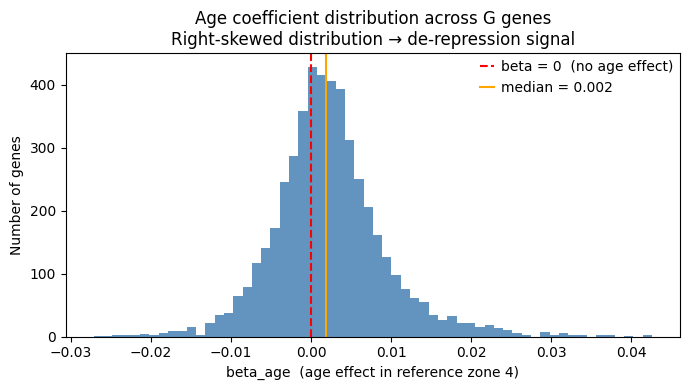

Mean   beta_age    : 0.0023
Median beta_age    : 0.0018
% genes with beta > 0 : 63.4%


In [30]:
# Find the column holding the main age coefficient
# Nebula names it logFC_<covariate_name>; we exclude interaction terms (which contain "zone")
age_beta_col = [c for c in df.columns if AGE in c and "logFC" in c and "zone" not in c]
print("Age beta column(s) found:", age_beta_col)

# Drop NaN rows — some genes may have failed to converge in Nebula
beta_age = df[age_beta_col[0]].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(beta_age, bins=60, color="steelblue", edgecolor="none", alpha=0.85)

# Vertical line at 0: this is where genes with no age effect cluster
ax.axvline(0, color="red", linestyle="--", lw=1.5, label="beta = 0  (no age effect)")

# Vertical line at the median: if positive, the typical gene in G increases with age
ax.axvline(beta_age.median(), color="orange", linestyle="-", lw=1.5,
           label=f"median = {beta_age.median():.3f}")

ax.set_xlabel(f"beta_age  (age effect in reference zone {REF_ZONE})")
ax.set_ylabel("Number of genes")
ax.set_title("Age coefficient distribution across G genes\n"
             "Right-skewed distribution → de-repression signal")
ax.legend()
plt.tight_layout()
plt.show()

# Key summary statistics
print(f"Mean   beta_age    : {beta_age.mean():.4f}")
print(f"Median beta_age    : {beta_age.median():.4f}")
print(f"% genes with beta > 0 : {(beta_age > 0).mean() * 100:.1f}%")

In [31]:
from scipy.stats import wilcoxon
stat, pval = wilcoxon(beta_age, alternative='greater')
print(f"Wilcoxon p-value (H0: median beta = 0): {pval:.2e}")


Wilcoxon p-value (H0: median beta = 0): 2.83e-104


# Per-zone age slopes
The `beta_age` above is the age effect **only in the reference zone (zone 1)**.
The interaction terms tell us how each other zone's slope differs from zone 1:
- Zone 1 slope = `logFC_age`
- Zone k slope = `logFC_age` + `logFC_age_x_zone_k`

In [32]:
# Identify the column holding the main age coefficient (slope in the reference zone)
age_main_col = [c for c in df.columns if AGE in c and "logFC" in c and "zone" not in c][0]
print("Age main column:", age_main_col)

# Reference zone slope = logFC_age directly
per_zone_slopes = {REF_ZONE: df[age_main_col].dropna()}

# For every other zone: total slope = reference slope + interaction delta
# Column names look like "logFC_age_x_zone_3" — extract the zone number with replace()
interaction_cols = [c for c in df.columns if "logFC_age_x_zone_" in c]

for col in interaction_cols:
    # Extract zone number: "logFC_age_x_zone_3" → 3
    zone_id = int(col.replace("logFC_age_x_zone_", ""))
    # Zone k slope = main age slope + interaction term for zone k
    per_zone_slopes[zone_id] = (df[age_main_col] + df[col]).dropna()

# Summary table: one row per zone showing median slope, mean slope, and % genes with positive slope
summary = pd.DataFrame({
    "zone":        sorted(per_zone_slopes),
    "median_beta": [per_zone_slopes[z].median() for z in sorted(per_zone_slopes)],
    "mean_beta":   [per_zone_slopes[z].mean()   for z in sorted(per_zone_slopes)],
    "pct_pos":     [(per_zone_slopes[z] > 0).mean() * 100 for z in sorted(per_zone_slopes)],
})
display(summary)

Age main column: logFC_age


,zone,median_beta,mean_beta,pct_pos
0,1,0.002565,0.003099,67.314451
1,2,0.000621,0.000645,54.579285
2,3,0.002276,0.001733,65.309076
3,4,0.001810,0.002258,63.448418
4,5,0.001210,0.000839,57.618358
5,6,0.002280,0.002289,63.076287


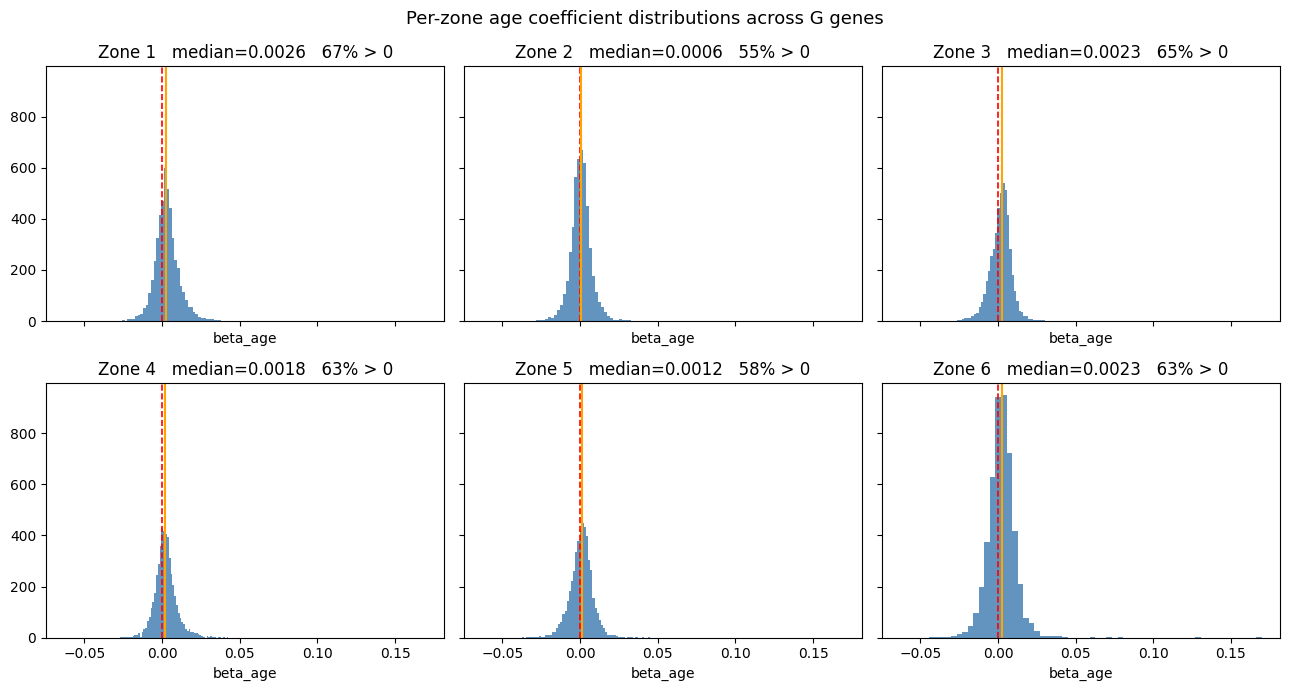

2026-06-02 21:44:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 21:44:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


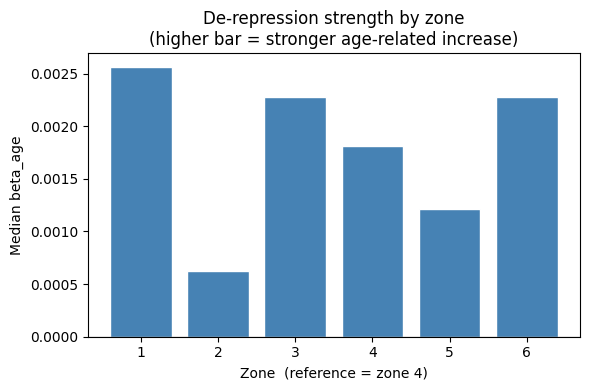

In [33]:
# One subplot per zone: distribution of age coefficients across all G genes
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, zone in zip(axes.flatten(), sorted(per_zone_slopes)):
    beta = per_zone_slopes[zone]

    ax.hist(beta, bins=60, color="steelblue", edgecolor="none", alpha=0.85)

    # Red dashed line at 0: null hypothesis (no age effect in this zone)
    ax.axvline(0, color="red", linestyle="--", lw=1.2)

    # Orange line at the median: typical age slope in this zone
    ax.axvline(beta.median(), color="orange", linestyle="-", lw=1.5)

    pct_pos = (beta > 0).mean() * 100
    ax.set_title(f"Zone {zone}   median={beta.median():.4f}   {pct_pos:.0f}% > 0")
    ax.set_xlabel("beta_age")

fig.suptitle("Per-zone age coefficient distributions across G genes", fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart: median beta per zone — at a glance which zones show the strongest de-repression
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(z) for z in summary["zone"]], summary["median_beta"],
       color="steelblue", edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(f"Zone  (reference = zone {REF_ZONE})")
ax.set_ylabel("Median beta_age")
ax.set_title("De-repression strength by zone\n(higher bar = stronger age-related increase)")
plt.tight_layout()
plt.show()

# Polycomb enrichment
Are polycomb / PRC2 target genes enriched among the most de-repressed G genes?

derepressed == beta_age  NEGATIVE --> os my universe must be only genes wiht pos beta 
dont care og gene lowly in Old (passed the first selectetion) but hihg in Y --> not derepression

Strategy: **Mann-Whitney U test** — tests whether polycomb targets have stochastically larger
`beta_age` values than non-targets. No significance cutoff required; works on the full distribution.


,category,n_in_geneset,n_in_G,median_beta,pct_pos,pval,fdr,sig
0,supp_table_3_PRC2_paper,179,28,0.008410,100.0,0.002138,0.004277,**
1,death_promoting_silenced_by_prc2,9,3,0.004877,100.0,0.653313,0.653313,


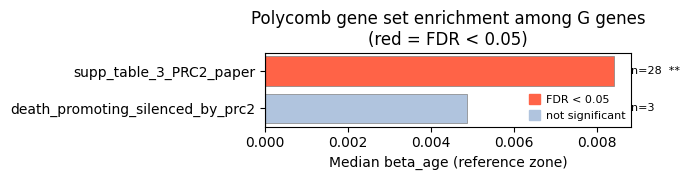

In [43]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Known Polycomb / PRC2 target gene sets — sourced from published ChIP-seq / supplementary tables
GENE_SETS = {
    "supp_table_3_PRC2_paper": [
        'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
        'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
        'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', 'LECT1', 'PYGL', 'DMRT3', 'TFAP2C',
        'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1', 'AMN', 'TMEM30B', 'IRX3',
        'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3', 'SIX6', 'TBX2', 'CD44',
        'ASB4', 'SCARF2', 'VGLL2', 'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10',
        'HOXA9', 'HOXC10', 'SLC6A5', 'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9',
        'HOXB7', 'HOXB8', 'MNX1', 'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2',
        'LUM', 'GATA2', 'PMAIP1', 'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1',
        'HMX1', 'TBX3', 'FOXA1', 'EBF3', 'HOXB13', 'EN1', 'HOXD13', 'LHX5',
        'HOXA7', 'HOXC5', 'NEUROD1', 'TFAP2A', 'HOXB5', 'SHOX2', 'TFAP2B',
        'NEUROD2', 'TLX1', 'TNNT2', 'SULT1A1', 'VAX2', 'HOXD11', 'CDKN1A',
        'NEUROG2', 'EOMES', 'PLIN4', 'TPBG', 'SSTR3', 'DLK1', 'PRDM8', 'HOXA4',
        'NRN1', 'VSX2', 'GFI1', 'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2',
        'MATN2', 'HOXB3', 'KRT1', 'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2',
        'HEYL', 'GSTA3', 'NKX2-5', 'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4',
        'SIX1', 'GRP', 'COL23A1', 'CIRBP', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
        'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'ISLR', 'ASB5', 'MYCL1', 'SDC1',
        'GATA4', 'BEND5', 'FXYD7', 'FOXL2', 'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25',
        'CLDN3', 'SLC6A7', 'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD',
        'GNA13', 'ALX1', 'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1',
        'CPA6', 'DMRT2', 'CPNE6', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
        'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2',
    ],
    "death_promoting_silenced_by_prc2": [
        "PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "IGFBP3", "TP73", "CDKN1A",
    ],
    "prc2_complex": [
        "EZH1", "EZH2", "EED", "SUZ12", "RBBP4", 
        "RBBP7", "MTF2", "PHF1", "PHF19", "PALI1", 
        "PALI2", "JARID2", "AEBP2"
    ],
    "prc1_complex": [
        "RING1", "RNF2", "PCGF1", "PCGF2", "PCGF3", 
        "PCGF4", "PCGF5", "PCGF6", "CBX2", "CBX4", 
        "CBX6", "CBX7", "CBX8", "PHC1", "PHC2", 
        "PHC3", "RYBP", "YAF2"
    ]
    # "hox": [
    #     "HOXA3", "HOXA4", "HOXA5", "HOXA7", "HOXA9", "HOXA10",
    #     "HOXB2", "HOXB3", "HOXB5", "HOXB6", "HOXB7", "HOXB8", "HOXB13",
    #     "HOXC4", "HOXC5", "HOXC8", "HOXC10",
    #     "HOXD3", "HOXD8", "HOXD9", "HOXD10", "HOXD11", "HOXD13",
    # ],
}

# Working table: gene name + main age coefficient, NaN rows removed
df_betas = df[["gene", age_main_col]].dropna().copy()


# ONLY POS BETAS
df_betas = df_betas[df_betas[age_main_col] > 0].copy()


# Minimum number of genes from a set that must be present in G to run the test
MIN_IN_G = 1

# ── Mann-Whitney U test for each gene set ──────────────────────────────────────
# H1 (one-sided): genes in the set have stochastically larger beta_age than the background
records = []

for category, gene_list in GENE_SETS.items():

    # Keep only genes from this set that are present in the Nebula results
    genes_in_G = [g for g in gene_list if g in df_betas["gene"].values]

    # Skip if too few genes are in G for a meaningful test
    if len(genes_in_G) < MIN_IN_G:
        continue

    # Beta values for this gene set and for all other genes (background)
    beta_set        = df_betas.loc[df_betas["gene"].isin(genes_in_G), age_main_col]
    beta_background = df_betas.loc[~df_betas["gene"].isin(genes_in_G), age_main_col]

    # One-sided Mann-Whitney: is the set stochastically greater than the background?
    _, pval = mannwhitneyu(beta_set, beta_background, alternative="greater")

    records.append({
        "category":     category,
        "n_in_geneset": len(gene_list),     # total genes in the curated set
        "n_in_G":       len(genes_in_G),    # how many of those are in our G
        "median_beta":  beta_set.median(),
        "pct_pos":      (beta_set > 0).mean() * 100,
        "pval":         pval,
    })

# Collect results and apply Benjamini-Hochberg FDR correction across gene sets
results = pd.DataFrame(records)
_, results["fdr"], _, _ = multipletests(results["pval"], method="fdr_bh")
results = results.sort_values("pval").reset_index(drop=True)

# Add a significance label for quick visual reading
results["sig"] = results["fdr"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
display(results)

# ── Forest-style horizontal bar chart ─────────────────────────────────────────
plot_df = results.sort_values("median_beta", ascending=True).reset_index(drop=True)

# Red bars = FDR < 0.05 (enriched); blue bars = not significant
colors = ["tomato" if fdr < 0.05 else "lightsteelblue" for fdr in plot_df["fdr"]]

fig, ax = plt.subplots(figsize=(7, 0.45 * len(plot_df) + 1))
ax.barh(plot_df["category"], plot_df["median_beta"], color=colors, edgecolor="grey", linewidth=0.5)
ax.axvline(0, color="black", lw=0.8)

# Annotate each bar with gene count and significance stars
for i, row in plot_df.iterrows():
    ax.text(plot_df["median_beta"].max() * 1.05, i,
            f"n={row['n_in_G']}  {row['sig']}", va="center", fontsize=8)

ax.set_xlabel("Median beta_age (reference zone)")
ax.set_title("Polycomb gene set enrichment among G genes\n(red = FDR < 0.05)")

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="tomato", label="FDR < 0.05"),
             Patch(color="lightsteelblue", label="not significant")],
    loc="lower right", fontsize=8,
)
plt.tight_layout()
plt.show()